<a href="https://colab.research.google.com/github/imouiche/Threat-Intelligence-Knowledge-Graphs/blob/main/re_securebert_bilstm_att.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import  drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
!pip install transformers datasets seqeval torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 23.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 18.5 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_

In [ ]:
import json
import re
import numpy as np
from torch.utils.data import Dataset, DataLoader
import csv
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import shutil
import torch

from collections import Counter, defaultdict
from datasets import load_dataset, ClassLabel
from seqeval.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.nn.functional import cross_entropy
from torch.optim import AdamW
from torch.utils.data import DataLoader, SubsetRandomSampler
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification, AutoConfig,
    DataCollatorForTokenClassification,
    get_scheduler
)

In [ ]:
def search_entity(sentence):
    e1_matches = re.findall(r'<e1>(.*)</e1>', sentence)
    e2_matches = re.findall(r'<e2>(.*)</e2>', sentence)

    if not e1_matches or not e2_matches:
        # Return None to indicate that the sentence should be skipped
        return None

    e1 = e1_matches[0]
    e2 = e2_matches[0]

    sentence = sentence.replace('<e1>' + e1 + '</e1>', ' <e1> ' + e1 + ' </e1> ', 1)
    sentence = sentence.replace('<e2>' + e2 + '</e2>', ' <e2> ' + e2 + ' </e2> ', 1)
    sentence = sentence.split()
    sentence = ' '.join(sentence)
    sentence = sentence.replace('< e1 >', '<e1>')
    sentence = sentence.replace('< e2 >', '<e2>')
    sentence = sentence.replace('< /e1 >', '</e1>')
    sentence = sentence.replace('< /e2 >', '</e2>')
    sentence = sentence.split()

    assert '<e1>' in sentence
    assert '<e2>' in sentence
    assert '</e1>' in sentence
    assert '</e2>' in sentence

    return sentence


def convert(path_src, path_des):
    with open(path_src, 'r', encoding='utf-8') as fr:
        data = fr.readlines()

    with open(path_des, 'w', encoding='utf-8') as fw:
        for i in range(0, len(data), 3):
            id_s, sentence = data[i].strip().split('  ')
            sentence = sentence[1:-1]

            # Process sentence using search_entity function
            sentence = search_entity(sentence)

            # Check if search_entity returned None
            if sentence is None:
                # Skip processing
                continue

            # Create a dictionary with metadata
            meta = dict(
                id=id_s,
                relation=data[i+1].strip(),
                sentence=sentence,
                comment=data[i+2].strip()
            )

            # Write the dictionary as a JSON object
            json.dump(meta, fw, ensure_ascii=False)

            fw.write('\n')


In [ ]:
#my_path = "/drive/MyDrive/datasets/relations_extraction/dnrti_re/"
my_path = "/drive/MyDrive/datasets/relations_extraction/dnrti_aug_re/"

In [ ]:
# path_train = my_path + 'pre_train.txt'
# path_test = my_path +'pre_test.txt'
# path_valid = my_path +'pre_test.txt'

# # # # path_train = my_path + 'pre_train.txt'
# # # # convert(path_train, my_path + '/pre_train1.json')

# convert(path_train, my_path + '/train.json')
# convert(path_test, my_path +'/test.json')
# convert(path_test, my_path +'/valid.json')

In [ ]:
OUTPUT_FILEPATHS = [
  os.path.join(my_path, "train.json"),
  os.path.join(my_path, "test.json"),
  os.path.join(my_path, "valid.json")
]

In [ ]:
data_files = {
    "train": OUTPUT_FILEPATHS[0],
    "validation": OUTPUT_FILEPATHS[1],
    "test": OUTPUT_FILEPATHS[2]
}
dataset = load_dataset("json", data_files=data_files)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 26544
    })
    validation: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 8849
    })
    test: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 8849
    })
})

In [ ]:
dataset["train"][2]

In [ ]:
from transformers import RobertaTokenizerFast, RobertaModel

In [ ]:
BASE_MODEL_NAME = "ehsanaghaei/SecureBERT"
#BASE_MODEL_NAME = "roberta-base"
tokenizer = RobertaTokenizerFast.from_pretrained(BASE_MODEL_NAME, add_prefix_space=True)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/815k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/473k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

In [ ]:
# Add special tokens
special_tokens_dict = {'additional_special_tokens': ['<e1>', '</e1>', '<e2>', '</e2>']}
num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)
print("We have added", num_added_toks, "tokens")

# Load the model
model = RobertaModel.from_pretrained(BASE_MODEL_NAME)
model.resize_token_embeddings(len(tokenizer))

We have added 4 tokens


config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at ehsanaghaei/SecureBERT and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(50269, 768)

In [ ]:
e1_id = tokenizer.convert_tokens_to_ids('<e1>')
e2_id = tokenizer.convert_tokens_to_ids('<e2>')
close_e1_id = tokenizer.convert_tokens_to_ids('</e1>')
close_e2_id = tokenizer.convert_tokens_to_ids('</e2>')

print("ID for '<e1>':", e1_id)
print("ID for '</e1>':", close_e1_id)
print("ID for '<e2>':", e2_id)
print("ID for '</e2>':", close_e2_id)

ID for '<e1>': 50265
ID for '</e1>': 50266
ID for '<e2>': 50267
ID for '</e2>': 50268


In [ ]:
def clean_sentence(sentence):
    if sentence:
        # Check if the first token starts with "
        if sentence[0].startswith('"'):
            sentence[0] = sentence[0][1:]  # Remove the " from the start of the first token
    return sentence
def clean_example(example):
    example['sentence'] = clean_sentence(example['sentence'])
    return example
dataset = dataset.map(clean_example)

Map:   0%|          | 0/26544 [00:00<?, ? examples/s]

Map:   0%|          | 0/8849 [00:00<?, ? examples/s]

Map:   0%|          | 0/8849 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 26544
    })
    validation: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 8849
    })
    test: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 8849
    })
})

In [ ]:
tokens = tokenizer(dataset["train"][0]["sentence"], is_split_into_words=True).tokens()
tokens

In [ ]:
input = tokenizer(dataset["train"][0]["sentence"], is_split_into_words=True)
word_ids = input.word_ids()
pd.DataFrame([tokens, word_ids], index=["sentence", "word_ids"])

,0,1,2,3,4,5,6,7,8,9,...,60,61,62,63,64,65,66,67,68,69
sentence,<s>,ĠThe,Ġmiddle,Ġeastern,Ġgroup,Ġin,Ġthis,Ġcase,Ġis,Ġcodenamed,...,Ġa,Ġnew,Ġblog,Ġpost,Ġpublished,Ġm,ond,ay,.,</s>
word_ids,None,0,1,2,3,4,5,6,7,8,...,41,42,43,44,45,46,46,46,46,None


In [ ]:
model.save_pretrained('my_model_directory/')  # Save the model and tokenizer
tokenizer.save_pretrained('my_model_directory/')

('my_model_directory/tokenizer_config.json',
 'my_model_directory/special_tokens_map.json',
 'my_model_directory/vocab.json',
 'my_model_directory/merges.txt',
 'my_model_directory/added_tokens.json',
 'my_model_directory/tokenizer.json')

# Tokenization

In [ ]:
BASE_MODEL_NAME = 'my_model_directory/'
tokenizer = RobertaTokenizerFast.from_pretrained(BASE_MODEL_NAME, add_prefix_space=True)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
def tokenize_function(examples):
    # Process each sentence in the batch
    sentences = [' '.join(sentence) for sentence in examples['sentence']]
    return tokenizer(sentences, padding="max_length", truncation=True, max_length=100)

# Apply the tokenizer across the dataset in batches
tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/26544 [00:00<?, ? examples/s]

Map:   0%|          | 0/8849 [00:00<?, ? examples/s]

Map:   0%|          | 0/8849 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'relation', 'sentence', 'comment', 'input_ids', 'attention_mask'],
        num_rows: 26544
    })
    validation: Dataset({
        features: ['id', 'relation', 'sentence', 'comment', 'input_ids', 'attention_mask'],
        num_rows: 8849
    })
    test: Dataset({
        features: ['id', 'relation', 'sentence', 'comment', 'input_ids', 'attention_mask'],
        num_rows: 8849
    })
})

In [ ]:
tokenized_datasets["train"][0]

In [ ]:
def create_relation_file(relations, data_dir=my_path):
    relation_file = os.path.join(data_dir, 'relation2id.txt')

    # Create a mapping between relations and IDs
    rel2id = {rel: str(idx) for idx, rel in enumerate(relations)}

    # Create the reverse mapping (ID to relation)
    id2rel = {str(idx): rel for idx, rel in enumerate(relations)}

    # Write the mapping to the relation2id.txt file
    with open(relation_file, 'w', encoding='utf-8') as fw:
        for rel, rel_id in rel2id.items():
            fw.write(f"{rel}\t{rel_id}\n")

    return rel2id, id2rel

In [ ]:
unique_relations = ['UKN', '<PAD>', 'targets(e1,e2)', 'uses(e1,e2)', 'targetedBy(e1,e2)',
       'hasAttackLocation(e1,e2)', 'hasLocation(e1,e2)',
       'associatedWith(e1,e2)', 'hasAttackTime(e1,e2)',
       'identifies(e1,e2)', 'monitors(e1,e2)', 'usedBy(e1,e2)',
       'affiliatedWith(e1,e2)', 'hasVulnerability(e1,e2)',
       'monitoredBy(e1,e2)', 'identifiedBy(e1,e2)', 'contains(e1,e2)']


#Normalized Dataset

# unique_relations = ['UKN', '<PAD>', 'targets(e1,e2)', 'uses(e1,e2)', 'targetedBy(e1,e2)',
#        'locatedAt(e1,e2)', 'hasAttackTime(e1,e2)', 'usedBy(e1,e2)',
#        'hasCharacteristics(e1,e2)', 'associatedWith(e1,e2)',
#        'discovers(e1,e2)', 'monitors(e1,e2)', 'motivatedBy(e1,e2)',
#        'discoveredBy(e1,e2)', 'monitoredBy(e1,e2)', 'motivates(e1,e2)',
#        'analyses(e1,e2)']

rel2id, id2rel = create_relation_file(unique_relations)

print("rel2id:", rel2id)
print("id2rel:", id2rel)

rel2id: {'UKN': '0', '<PAD>': '1', 'targets(e1,e2)': '2', 'uses(e1,e2)': '3', 'targetedBy(e1,e2)': '4', 'hasAttackLocation(e1,e2)': '5', 'hasLocation(e1,e2)': '6', 'associatedWith(e1,e2)': '7', 'hasAttackTime(e1,e2)': '8', 'identifies(e1,e2)': '9', 'monitors(e1,e2)': '10', 'usedBy(e1,e2)': '11', 'affiliatedWith(e1,e2)': '12', 'hasVulnerability(e1,e2)': '13', 'monitoredBy(e1,e2)': '14', 'identifiedBy(e1,e2)': '15', 'contains(e1,e2)': '16'}
id2rel: {'0': 'UKN', '1': '<PAD>', '2': 'targets(e1,e2)', '3': 'uses(e1,e2)', '4': 'targetedBy(e1,e2)', '5': 'hasAttackLocation(e1,e2)', '6': 'hasLocation(e1,e2)', '7': 'associatedWith(e1,e2)', '8': 'hasAttackTime(e1,e2)', '9': 'identifies(e1,e2)', '10': 'monitors(e1,e2)', '11': 'usedBy(e1,e2)', '12': 'affiliatedWith(e1,e2)', '13': 'hasVulnerability(e1,e2)', '14': 'monitoredBy(e1,e2)', '15': 'identifiedBy(e1,e2)', '16': 'contains(e1,e2)'}


In [ ]:
len(rel2id)

17

In [ ]:
class RoBERTaBrevetsDataset(Dataset):
    def __init__(self, filename, rel2id, tokenizer, max_len):
        self.filename = os.path.join(my_path, filename)
        self.rel2id = rel2id
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.dataset, self.label = self.__load_data()

    def __load_data(self):
        data = []
        labels = []
        with open(self.filename, 'r', encoding='utf-8') as fr:
            for line in fr:
                line = json.loads(line.strip())
                label = self.rel2id[line['relation']]
                sentence = ' '.join(line['sentence'])  # Join tokens to form a single string
                # Ensure label is an integer
                label_idx = int(label)

                # Tokenize and encode the sentence
                inputs = self.tokenizer(sentence, max_length=self.max_len, padding='max_length', truncation=True, return_tensors="pt")
                data.append(inputs)
                labels.append(label_idx)
        return data, labels


    def __getitem__(self, index):
        inputs = self.dataset[index]
        label = self.label[index]
        #print(f"Label type: {type(label)}, Label: {label}")
        return inputs, label

    def __len__(self):
        return len(self.label)

In [ ]:
class RoBERTaBrevetsDataLoader(object):
    def __init__(self, rel2id, tokenizer, batch_size, max_len):
        self.rel2id = rel2id
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.max_len = max_len

    def __collate_fn(self, batch):
        # Concatenate input_ids and attention_masks from all samples in the batch
        input_ids = torch.cat([item[0]['input_ids'] for item in batch], dim=0)
        attention_mask = torch.cat([item[0]['attention_mask'] for item in batch], dim=0)

       # print([item[1] for item in batch])
        # Ensure labels are simply collected into a tensor
        labels = torch.tensor([item[1] for item in batch], dtype=torch.long)

        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}


    def __get_data(self, filename, shuffle=False):
        dataset = RoBERTaBrevetsDataset(filename, self.rel2id, self.tokenizer, self.max_len)
        loader = DataLoader(
            dataset=dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            collate_fn=self.__collate_fn
        )
        return loader

    def get_train(self):
        return self.__get_data('train.json', shuffle=True)

    def get_dev(self):
        return self.__get_data('valid.json', shuffle=False)

    def get_test(self):
        return self.__get_data('test.json', shuffle=False)

In [ ]:
batch_size = 16
max_len = 100
loader = RoBERTaBrevetsDataLoader(rel2id, tokenizer, batch_size, max_len)
test_loader = loader.get_test()
train_loader = loader.get_train()
valid_loader = loader.get_dev()

In [ ]:
train_loader

In [ ]:
for batch in test_loader:
    input_ids = batch['input_ids']
    attention_mask = batch['attention_mask']
    labels = batch['labels']

    print("Input IDs:", input_ids)
    print("Attention Mask:", attention_mask)
    print("Labels:", labels)
    break

Input IDs: tensor([[    0,    22,  2709,  ...,     1,     1,     1],
        [    0,    22,   133,  ...,     1,     1,     1],
        [    0,    22,   170,  ...,     1,     1,     1],
        ...,
        [    0,    22,  1121,  ...,     1,     1,     1],
        [    0,    22, 11321,  ...,     1,     1,     1],
        [    0,    22,   133,  ...,  9484,     4,     2]])
Attention Mask: tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]])
Labels: tensor([ 5,  2,  5, 11,  4,  3, 12,  4,  8,  3, 11,  4,  8,  5,  5,  3])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class RoBERTaBiLSTMAtt(nn.Module):
    def __init__(self, class_num, hidden_size, layers_num, dropout, max_len):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained('my_model_directory/')
        self.class_num = class_num
        self.hidden_size = hidden_size
        self.layers_num = layers_num
        self.dropout_value = dropout
        self.max_len = max_len

        # Store the RoBERTa config as an attribute for easy access
        self.config = self.roberta.config

        self.lstm = nn.LSTM(
            input_size=self.config.hidden_size,
            hidden_size=self.hidden_size,
            num_layers=self.layers_num,
            bias=True,
            batch_first=True,
            dropout=self.dropout_value if self.layers_num > 1 else 0,
            bidirectional=True
        )
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(self.dropout_value)
        self.att_weight = nn.Parameter(torch.randn(1, 2 * self.hidden_size, 1))
        self.dense = nn.Linear(
            in_features=2 * self.hidden_size,
            out_features=self.class_num,
            bias=True
        )
        nn.init.xavier_normal_(self.dense.weight)
        nn.init.constant_(self.dense.bias, 0)

    def attention_layer(self, h, mask):
        att_weight = self.att_weight.expand(h.size(0), -1, -1)
        h = self.tanh(h)
        att_score = torch.bmm(h, att_weight)
        if mask.dim() == 2:
            mask = mask.unsqueeze(-1)
        att_score = att_score.masked_fill(mask == 0, float('-inf'))
        att_weight = torch.softmax(att_score, dim=1)
        reps = torch.bmm(h.transpose(1, 2), att_weight).squeeze(-1)
        return self.tanh(reps)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        lengths = attention_mask.sum(1).cpu()
        packed_output = pack_padded_sequence(sequence_output, lengths, batch_first=True, enforce_sorted=False)
        lstm_output, _ = self.lstm(packed_output)
        lstm_output, _ = pad_packed_sequence(lstm_output, batch_first=True)
        effective_length = lstm_output.size(1)
        adjusted_mask = attention_mask[:, :effective_length]
        reps = self.attention_layer(lstm_output, adjusted_mask)
        reps = self.dropout(reps)
        logits = self.dense(reps)
        return logits


In [ ]:
!pip install pytorch-crf

# Model Architecture

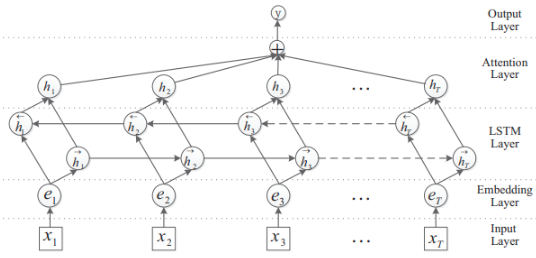

In [ ]:
class_num = len(rel2id)
#class_num = len(rel2id) + 1

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = RoBERTaBiLSTMAtt(
  #  bert_model_name='bert-base-uncased',
    class_num=class_num,  # define your number of classes
    hidden_size=100,
    layers_num=1,
    dropout=0.5,
    max_len=100
).to(device)


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
print(model.config)

RobertaConfig {
  "_name_or_path": "my_model_directory/",
  "architectures": [
    "RobertaModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.41.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50269
}



In [ ]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Number of trainable parameters: {total_params:,}')

count_parameters(model)

Number of trainable parameters: 125,348,882


In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss().to(device)

def setup_optimizer(model, lr=2e-5, eps=1e-8, weight_decay_rate=0.01, second_weight_decay_rate=0.0):
    param_optimizer = list(model.named_parameters())
    no_decay = ['bias', 'LayerNorm.weight']  # Updated 'LayerNorm.weight' based on BERT's architecture

    optimizer_grouped_parameters = [
        {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
         'weight_decay': weight_decay_rate},  # use 'weight_decay' instead of 'weight_decay_rate'
        {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
         'weight_decay': second_weight_decay_rate}
    ]

    optimizer = optim.AdamW(optimizer_grouped_parameters, lr=lr, eps=eps)
    return optimizer



In [ ]:
from sklearn.metrics import f1_score
import numpy as np

def calculate_f1_scores(predicted_labels, true_labels):
    # Calculate F1 scores
    micro_f1 = f1_score(true_labels, predicted_labels, average='micro')
    macro_f1 = f1_score(true_labels, predicted_labels, average='macro')

    return micro_f1, macro_f1

In [ ]:
def train_model(model, iterator, optimizer, criterion, device):
    model.train()  # Ensure the model is in training mode
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in iterator:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().detach().numpy())
        all_labels.extend(labels.cpu().detach().numpy())

    avg_loss = total_loss / len(iterator)
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return micro_f1, macro_f1, avg_loss


In [ ]:
import torch
import numpy as np
from sklearn.metrics import f1_score

def evaluate(model, iterator, criterion, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().detach().numpy())
            all_labels.extend(labels.cpu().detach().numpy())

    # Compute the average loss
    avg_loss = total_loss / len(iterator)

    # Calculate F1 scores
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return micro_f1, macro_f1, avg_loss, all_preds, all_labels


In [ ]:
import time
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
import time
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def entrainement(model, train_loader, valid_loader, optimizer, criterion, device, N_EPOCHS=55, model_path='model.pt'):
    t_loss = []
    t_micro_f1 = []
    t_macro_f1 = []
    v_loss = []
    v_micro_f1 = []
    v_macro_f1 = []
    best_valid_loss = float('inf')

    for epoch in range(N_EPOCHS):
        start_time = time.time()


        train_micro_f1, train_macro_f1, train_loss = train_model(model, train_loader, optimizer, criterion, device)
        t_loss.append(train_loss)
        t_micro_f1.append(train_micro_f1)
        t_macro_f1.append(train_macro_f1)


        valid_micro_f1, valid_macro_f1, valid_loss,_,_ = evaluate(model, valid_loader, criterion, device)
        v_loss.append(valid_loss)
        v_micro_f1.append(valid_micro_f1)
        v_macro_f1.append(valid_macro_f1)

        end_time = time.time()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), model_path)

        print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train Micro F1: {train_micro_f1*100:.2f}% | Train Macro F1: {train_macro_f1*100:.2f}%')
        print(f'\tVal. Loss: {valid_loss:.3f} | Val. Micro F1: {valid_micro_f1*100:.2f}% | Val. Macro F1: {valid_macro_f1*100:.2f}%')

    return t_loss, v_loss, t_micro_f1, v_micro_f1, t_macro_f1, v_macro_f1


In [ ]:

# model = RoBERTaBiLSTMAttCRF(
#   #  bert_model_name='bert-base-uncased',
#     class_num=class_num,  # define your number of classes
#     hidden_size=100,
#     layers_num=1,
#     dropout=0.5,
#     max_len=100
# ).to(device)

In [ ]:
optimizer = setup_optimizer(model, lr=3e-5, weight_decay_rate=1e-5)

In [ ]:
N_EPOCHS = 4

# Start the training process
t_l, v_l,  t_micro_f1, v_micro_f1, t_macro_f1, v_macro_f1 = entrainement(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    N_EPOCHS=N_EPOCHS
)

Epoch: 01 | Epoch Time: 8m 44s
	Train Loss: 0.993 | Train Micro F1: 69.99% | Train Macro F1: 56.66%
	Val. Loss: 0.351 | Val. Micro F1: 90.65% | Val. Macro F1: 87.73%
Epoch: 02 | Epoch Time: 8m 45s
	Train Loss: 0.321 | Train Micro F1: 92.39% | Train Macro F1: 89.66%
	Val. Loss: 0.249 | Val. Micro F1: 94.62% | Val. Macro F1: 92.34%
Epoch: 03 | Epoch Time: 8m 45s
	Train Loss: 0.232 | Train Micro F1: 95.08% | Train Macro F1: 93.31%
	Val. Loss: 0.252 | Val. Micro F1: 95.25% | Val. Macro F1: 93.56%
Epoch: 04 | Epoch Time: 8m 44s
	Train Loss: 0.181 | Train Micro F1: 96.49% | Train Macro F1: 95.29%
	Val. Loss: 0.245 | Val. Micro F1: 95.51% | Val. Macro F1: 94.22%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set()

def plot_metrics(N_EPOCHS, t_loss, v_loss, t_micro_f1, v_micro_f1, t_macro_f1, v_macro_f1):
    f = plt.figure(figsize=(6, 6))  # Increase figure size for better visibility
    gs = f.add_gridspec(3, 1)  # Add an additional grid for macro F1 scores
    plt.subplots_adjust(hspace=0.4)  # Adjust horizontal space
    x = np.linspace(0, N_EPOCHS, N_EPOCHS)

    # Plotting Loss
    with sns.axes_style("darkgrid"):
        ax = f.add_subplot(gs[0])
        plt.plot(x, t_loss, label='Train Loss')
        plt.plot(x, v_loss, label='Valid Loss')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Training and Validation Loss")

    # Plotting Micro F1 Score
    ax = f.add_subplot(gs[1])
    plt.plot(x, t_micro_f1, label='Train F1 Score')
    plt.plot(x, v_micro_f1, label='Valid F1 Score')
    plt.xlabel("Epochs")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.title("Training and Validation F1 Score")

    # Plotting Macro F1 Score
    # ax = f.add_subplot(gs[2])
    # plt.plot(x, t_macro_f1, label='Train Macro F1 Score')
    # plt.plot(x, v_macro_f1, label='Valid Macro F1 Score')
    # plt.xlabel("Epochs")
    # plt.ylabel("Macro F1 Score")
    # plt.legend()
    # plt.title("Training and Validation Macro F1 Score")

    f.tight_layout()  # Adjust layout to fit all subplots neatly
    plt.show()


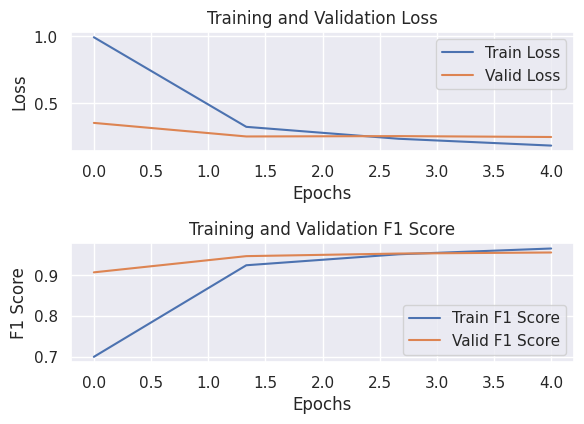

In [ ]:
# Call the function with the appropriate arguments
plot_metrics(N_EPOCHS, t_l, v_l, t_micro_f1, v_micro_f1, t_macro_f1, v_macro_f1)

In [ ]:
import torch

model_path ='/content/model.pt'


model.load_state_dict(torch.load(model_path))
model.to(device)

micro_f1, macro_f1, eval_loss, preds, labels = evaluate(model, test_loader, criterion, device)

# Print the evaluation results
print(f'Test Loss: {eval_loss:.3f}')
print(f'Test Micro F1 Score: {micro_f1*100:.2f}%')
print(f'Test Macro F1 Score: {macro_f1*100:.2f}%')

Test Loss: 0.245
Test Micro F1 Score: 95.51%
Test Macro F1 Score: 94.22%


In [ ]:
def evaluate(model, iterator, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(iterator)
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return micro_f1, macro_f1, avg_loss, all_preds, all_labels


In [ ]:
# Unpacking returned values including predictions and labels
micro_f1, macro_f1, eval_loss, preds, labels = evaluate(model, test_loader, criterion, device)

In [ ]:
from sklearn.metrics import classification_report

# Assuming rel2id is your dictionary mapping relation names to their numeric IDs
# Excluding both '<PAD>' and 'UKN' from the classification report

# Creating list of labels to include in the report (numeric IDs)
positive_labels = [int(v) for k, v in rel2id.items() if k not in ['<PAD>', 'UKN']]

# Creating human-readable names for these labels
positive_names = [k for k, v in rel2id.items() if k not in ['<PAD>', 'UKN']]

# Generate and print the classification report
print(classification_report(
    y_true=labels,
    y_pred=preds,
    labels=positive_labels,  # Numeric IDs of the labels
    target_names=positive_names,  # Human-readable names
    digits=4  # Optional: Number of digits to format output
))

                          precision    recall  f1-score   support

          targets(e1,e2)     0.9847    0.9645    0.9745      1606
             uses(e1,e2)     0.9530    0.9526    0.9528      2256
       targetedBy(e1,e2)     0.9753    0.9573    0.9662       702
hasAttackLocation(e1,e2)     0.9908    0.9908    0.9908       762
      hasLocation(e1,e2)     0.9953    1.0000    0.9977       428
   associatedWith(e1,e2)     0.9110    0.9330    0.9219       911
    hasAttackTime(e1,e2)     1.0000    0.9909    0.9954       331
       identifies(e1,e2)     0.9380    0.9806    0.9588       463
         monitors(e1,e2)     0.9673    0.9024    0.9338       164
           usedBy(e1,e2)     0.8822    0.9105    0.8961       592
   affiliatedWith(e1,e2)     0.8981    0.8981    0.8981       206
 hasVulnerability(e1,e2)     0.9394    0.9775    0.9581       222
      monitoredBy(e1,e2)     0.9778    0.9565    0.9670        46
     identifiedBy(e1,e2)     0.8876    0.9405    0.9133        84
         

In [ ]:
labels

In [ ]:
import pandas as pd

confusion = confusion_matrix(labels, preds)
l = positive_names

confusion_df =pd.DataFrame(confusion)

confusion_df.columns=l
s = pd.Series(l)
confusion_df = confusion_df.set_index([s])


confusion_df

,"targets(e1,e2)","uses(e1,e2)","targetedBy(e1,e2)","hasAttackLocation(e1,e2)","hasLocation(e1,e2)","associatedWith(e1,e2)","hasAttackTime(e1,e2)","identifies(e1,e2)","monitors(e1,e2)","usedBy(e1,e2)","affiliatedWith(e1,e2)","hasVulnerability(e1,e2)","monitoredBy(e1,e2)","identifiedBy(e1,e2)","contains(e1,e2)"
"targets(e1,e2)",1568,19,1,2,0,4,0,0,1,3,2,6,0,0,0
"uses(e1,e2)",34,2078,17,0,0,46,0,39,1,21,3,1,8,7,1
"targetedBy(e1,e2)",0,1,663,0,2,10,0,14,0,6,1,4,1,0,0
"hasAttackLocation(e1,e2)",6,2,0,751,1,1,0,0,0,1,0,0,0,0,0
"hasLocation(e1,e2)",0,0,0,1,425,0,0,1,1,0,0,0,0,0,0
"associatedWith(e1,e2)",7,62,11,0,0,773,0,1,0,42,10,1,0,0,4
"hasAttackTime(e1,e2)",3,0,0,0,0,0,327,0,0,0,0,0,0,1,0
"identifies(e1,e2)",0,2,0,0,1,0,0,458,0,0,2,0,0,0,0
"monitors(e1,e2)",1,0,0,0,0,0,0,21,142,0,0,0,0,0,0
"usedBy(e1,e2)",12,32,6,1,0,38,0,2,0,496,2,2,0,0,1
